In [1]:
%load_ext autoreload
%autoreload 2

In [35]:
import pandas as pd
from analysis_tools.workflows.evaluation_flow import evaluation_flow
from analysis_tools.workflows.BDT_pipeline import run_bdt_pipeline, run_bdt_pipeline_hese
from analysis_tools.namings.BDT_feature_naming import BDT_feature_name_change
from analysis_tools.BDT_tools.Testset_preparation import create_learning_input,annotate_labels
from analysis_tools.BDT_tools.BDT_evaluation import find_best_two_bdt_thresholds,plot_bdt_threshold_scan
from analysis_tools.workflows.prediction_flow import prediction_flow,predict_scores
from analysis_tools.my_selectors.apply_selection import apply_selection


In [3]:
model_configs = [
  {
    'name':'bdt1',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['TrueLength'] > 10),
    'bg_mask' : 'bg_bdt1'  
  },
  {
    'name':'bdt2',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['TrueLength'] > 10),
    'bg_mask' :'bg_bdt2'
  }
]

In [4]:
df_train = pd.read_parquet("/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/bdt/SnowStorm_v2_HESE_Baseline_v5_noMuon/dataset_IC86_pass2_SnowStorm_v2_FTP_v5_noMuon.parquet")
df_test = df_train.copy()

In [5]:
Taupede_name = "TaupedeFit_iMIGRAD_PPB0"
precut_dict = {
'MonopodFit_iMIGRAD_PPB0_energy':('>', 10**4.5),
'Taupede_Distance':[('>', 10),('<', 400)],
  f'{Taupede_name}_1_x':[('>', -500),('<', 500)],
  f'{Taupede_name}_1_y':[('>', -500),('<', 500)],
  f'{Taupede_name}_1_z':{'and':[('>', -500),('<', 500)],
                                  'or':[('>', -50), ('<', -150)]},
  f'{Taupede_name}_2_x':[('>', -500),('<', 500)],
  f'{Taupede_name}_2_y':[('>', -500),('<', 500)],
  f'{Taupede_name}_2_z':{'and':[('>', -500),('<', 500)],
                                  'or':[('>', -50), ('<', -150)]},
}

df_train_precut = apply_selection(df_train,precut_dict).copy()
df_test_precut = apply_selection(df_test,precut_dict).copy()

per_flavor_norm = 2.12
gamma_astro = 2.87
norm_factor = 0.5 * per_flavor_norm * 1e-18
for df in (df_train_precut, df_test_precut):
    e = df["MCPrimaryEnergy"] / 1e5
    df["fluxless_weight"] = df["powerlaw"] * 1e18 * e**2
    df["weight"] = df["fluxless_weight"] * norm_factor * e**(-gamma_astro)

In [6]:
features_list = [
'TauMonoDiff_rlogl',
'Taupede_Asymmetry',
'Taupede_Distance',
'Taupede1_Particles_energy',
'Taupede2_Particles_energy',
'cscdSBU_MonopodFit4_noDC_zenith',
'MonopodFit_iMIGRAD_PPB0_Delay_ice',
'CVStatistics_q_max_doms',
'cscdSBU_VertexRecoDist_CscdLLh',
'MonopodFit_iMIGRAD_PPB0_energy',
'cscdSBU_Qtot_HLC_log',
# 'Taupede_ftpFitParams_rlogl', # bad data/mc
# 'cscdSBU_MonopodFit4_noDCFitParams_rlogl', # bad data/mc
]

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_benchmark_v0/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_benchmark_v0/bdt1_model.pkl


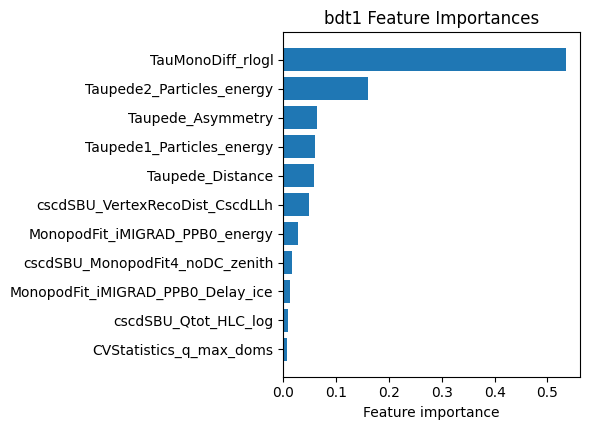

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_benchmark_v0/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_benchmark_v0/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_benchmark_v0/bdt2_model.pkl


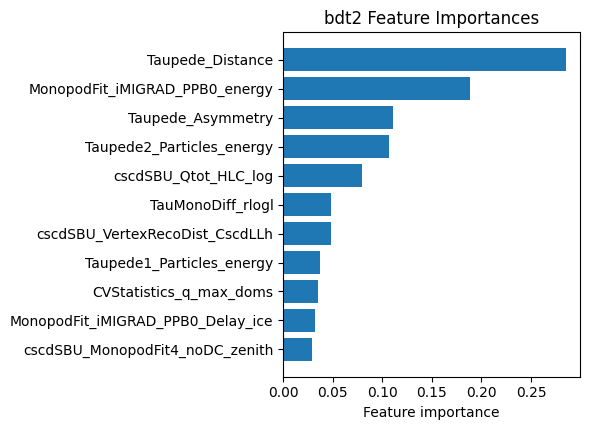

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_benchmark_v0/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 34458
[weight] rate        = 4.7205e-08
[weight] uncertainty = 5.68053e-10
Calculating rates for flavor: numu
Raw event count: 42593
[weight] rate        = 2.74859e-08
[weight] uncertainty = 2.85702e-10
Calculating rates for flavor: nutau
Raw event count: 52638
[weight] rate        = 3.32846e-08
[weight] uncertainty = 4.17735e-10


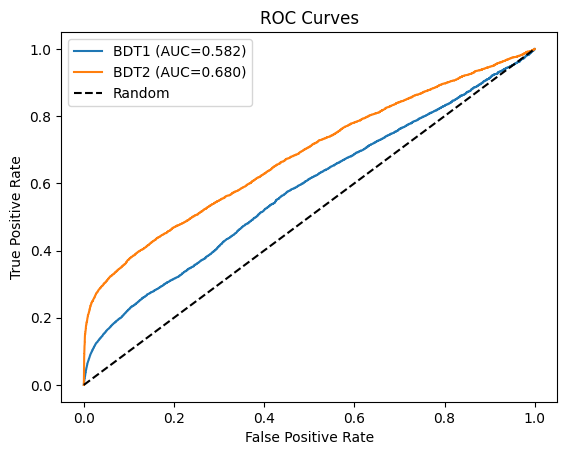

saving roc curves


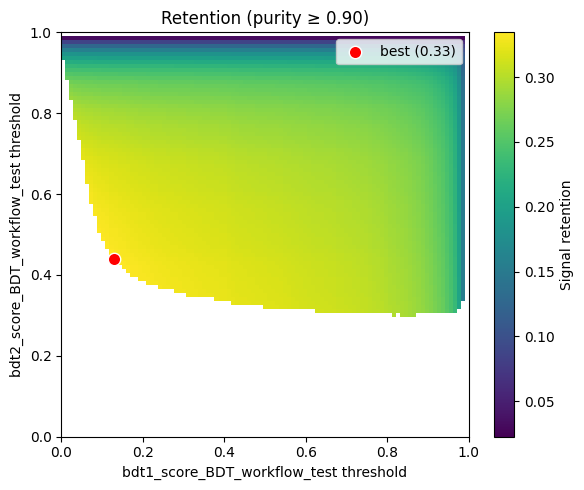


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 1050
[weight] rate        = 5.4474e-10
[weight] uncertainty = 4.20873e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 5063
[weight] rate        = 6.73205e-10
[weight] uncertainty = 2.94661e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 34163
[weight] rate        = 1.11345e-08
[weight] uncertainty = 1.7368e-10


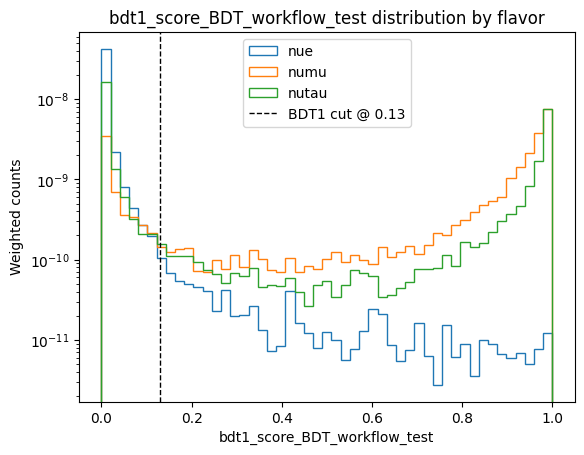

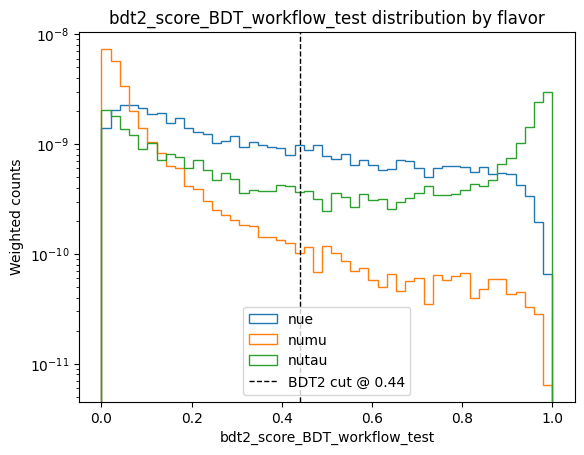

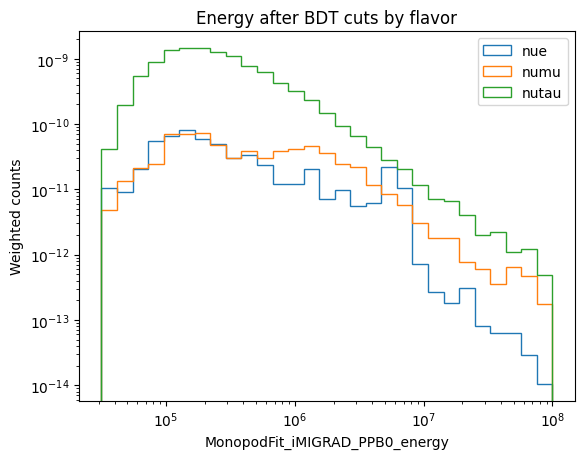


Final purity: 0.901, efficiency: 0.335


In [7]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_benchmark_v0/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/eval_output_benchmark_v0/'
) 

Now lets add some true containment to the signal/bg flags, all events are already contained?! so I guess it wont change anything

In [23]:
model_configs = [
  {
    'name':'bdt1',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['TrueLength'] > 10) &
                   (df['TrueContained1'] == True) &
                   (df['TrueContained2'] == True),
    'bg_mask' : 'bg_bdt1'  
  },
  {
    'name':'bdt2',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['TrueLength'] > 10) &
                   (df['TrueContained1'] == True) &
                   (df['TrueContained2'] == True),
    'bg_mask' :'bg_bdt2'
  }
]

In [24]:
print("total events", len(df))
print("total cascade", sum(df["MCInteractionEventclass"] == 1))
print("total double", sum(df["MCInteractionEventclass"] == 2))
print("total track", sum(df["MCInteractionEventclass"] == 3))
print("not contained 1", sum( df["TrueContained1"] == False ))
print("not contained 2", sum( df["TrueContained2"] == False ))
print("not contained both", sum( (df["TrueContained1"] == False) &  (df["TrueContained2"] == False) ))

total events 129689
total cascade 45733
total double 33329
total track 50627
not contained 1 227
not contained 2 299
not contained both 49


Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_contained/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_contained/bdt1_model.pkl


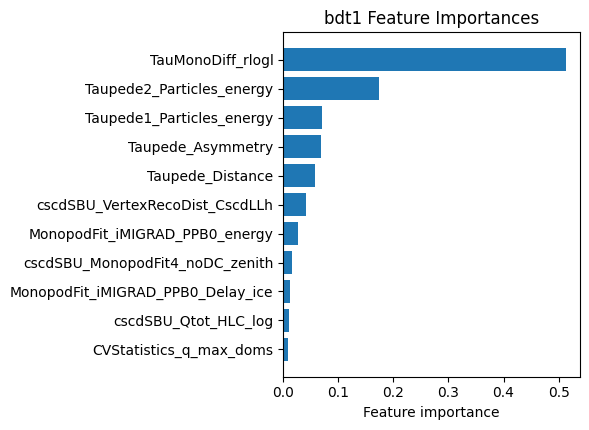

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_contained/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_contained/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_contained/bdt2_model.pkl


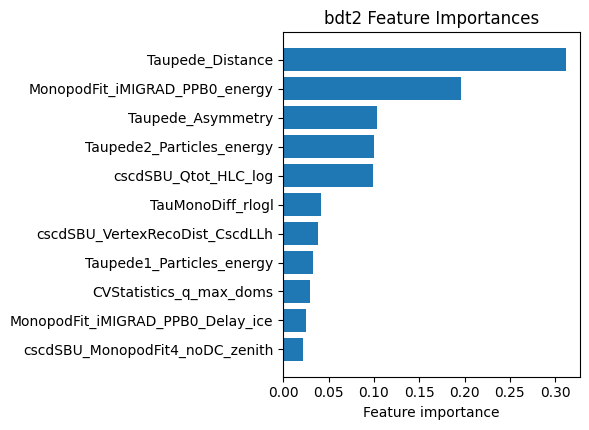

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_contained/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 34458
[weight] rate        = 4.7205e-08
[weight] uncertainty = 5.68053e-10
Calculating rates for flavor: numu
Raw event count: 42593
[weight] rate        = 2.74859e-08
[weight] uncertainty = 2.85702e-10
Calculating rates for flavor: nutau
Raw event count: 52638
[weight] rate        = 3.32846e-08
[weight] uncertainty = 4.17735e-10


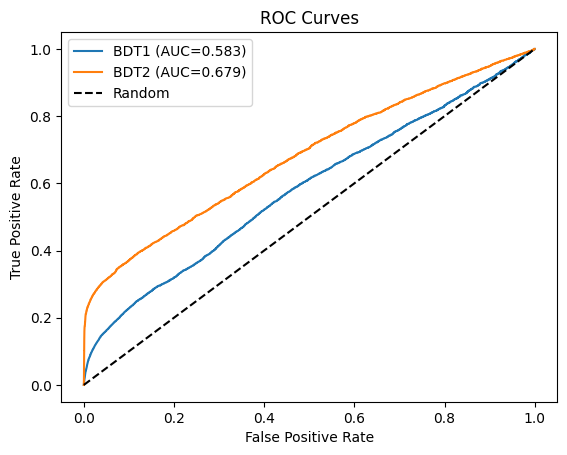

saving roc curves


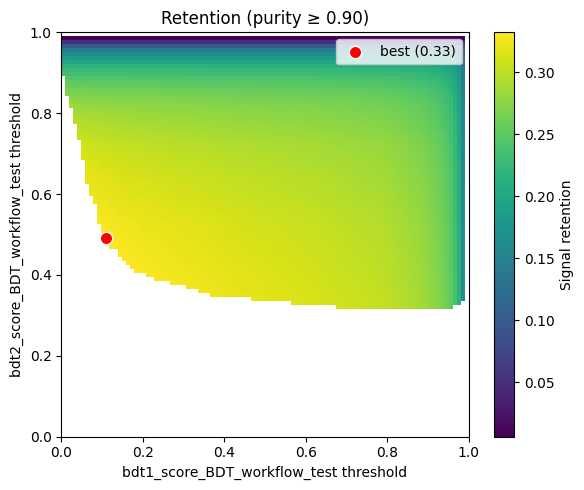


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 1089
[weight] rate        = 5.67016e-10
[weight] uncertainty = 4.3792e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 4693
[weight] rate        = 6.3557e-10
[weight] uncertainty = 2.96243e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 32736
[weight] rate        = 1.10506e-08
[weight] uncertainty = 1.72812e-10


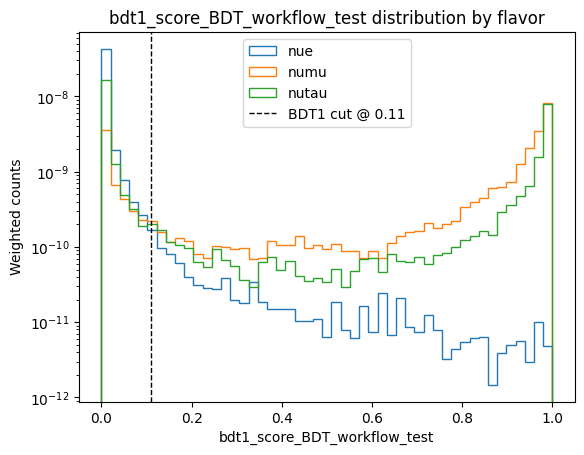

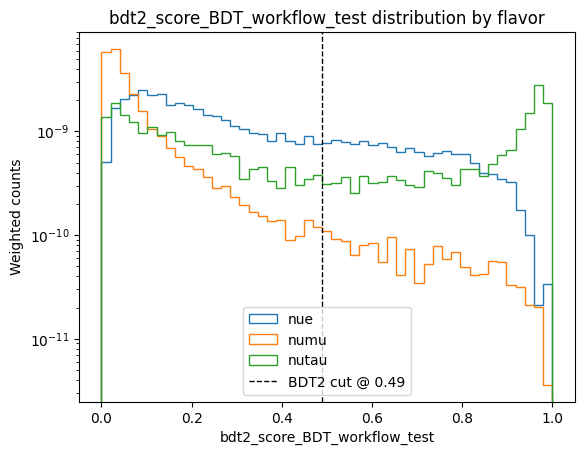

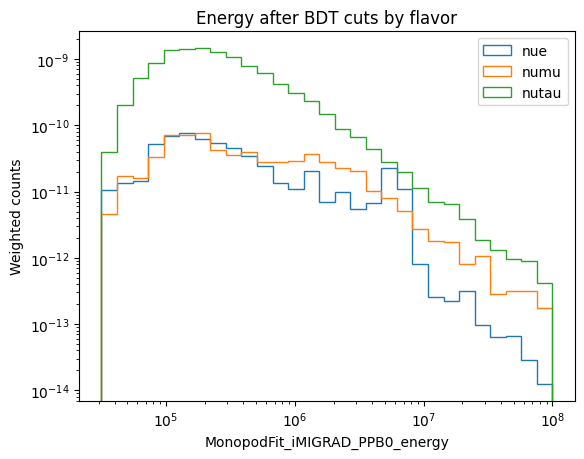


Final purity: 0.902, efficiency: 0.332


In [25]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_contained/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/eval_output_true_contained/'
) 

That doesnt do anything, i remove it, and now I train on actual double cascades/tracks/singles

In [30]:
model_configs = [
  {
    'name':'bdt1',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['TrueLength'] > 10),
    'bg_mask' : 'bg_bdt1'  
  },
  {
    'name':'bdt2',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['TrueLength'] > 10),
    'bg_mask' :'bg_bdt2'
  }
]

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology/bdt1_model.pkl


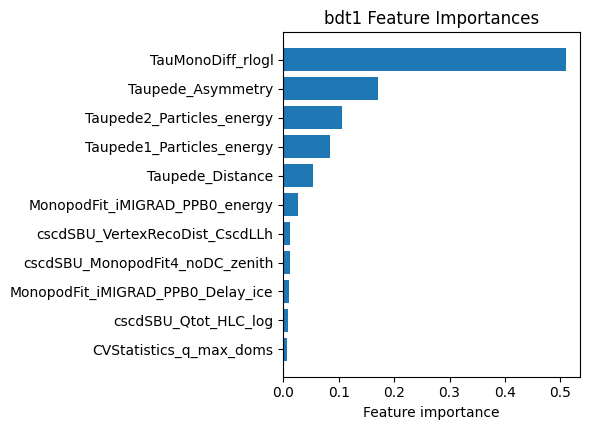

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology/bdt2_model.pkl


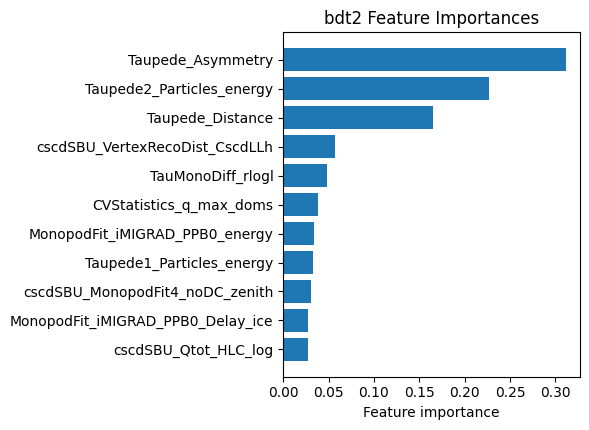

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 34458
[weight] rate        = 4.7205e-08
[weight] uncertainty = 5.68053e-10
Calculating rates for flavor: numu
Raw event count: 42593
[weight] rate        = 2.74859e-08
[weight] uncertainty = 2.85702e-10
Calculating rates for flavor: nutau
Raw event count: 52638
[weight] rate        = 3.32846e-08
[weight] uncertainty = 4.17735e-10


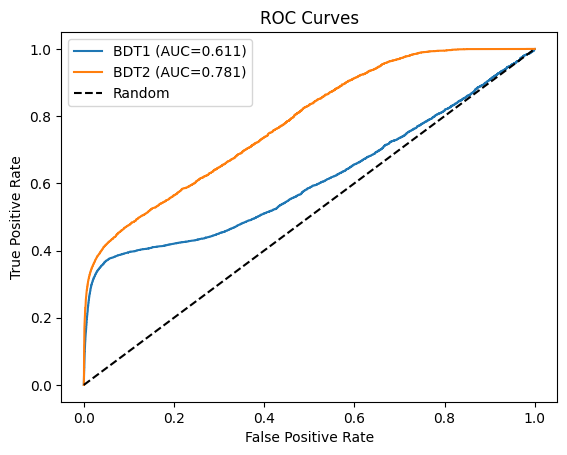

saving roc curves


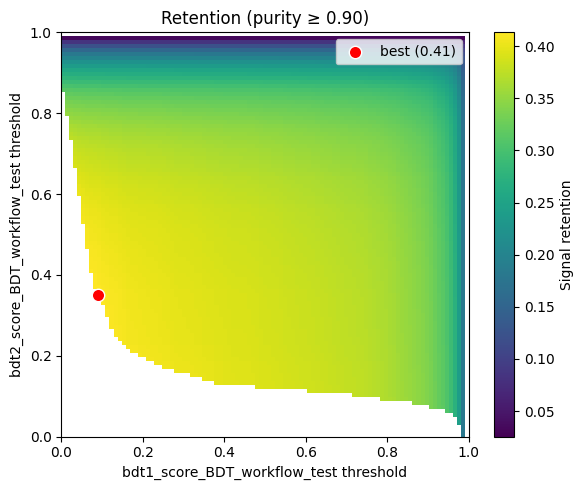


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 831
[weight] rate        = 5.37296e-10
[weight] uncertainty = 3.65469e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 2857
[weight] rate        = 4.92983e-10
[weight] uncertainty = 2.75595e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 27865
[weight] rate        = 1.10793e-08
[weight] uncertainty = 1.73828e-10


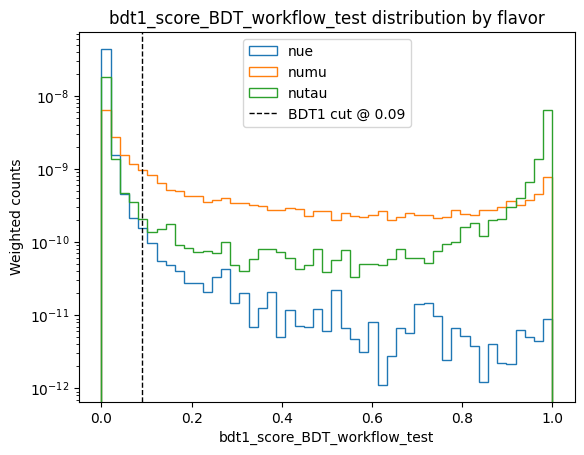

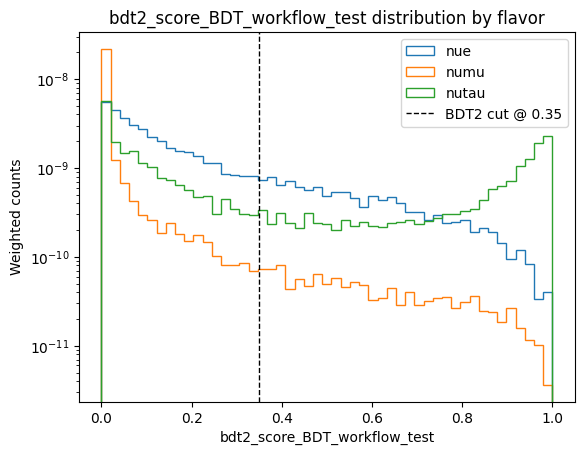

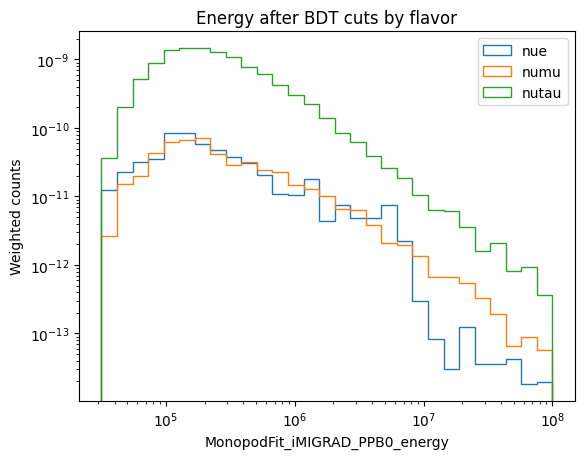


Final purity: 0.915, efficiency: 0.333


In [32]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline_hese(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/eval_output_true_topology/'
) 

In [34]:
model_configs = [
  {
    'name':'bdt1',
    'sig_mask': lambda df: 
                   (df['sig_bdt1_trackfirst']) & 
                   (df['TrueLength'] > 10),
    'bg_mask' : 'bg_bdt1_trackfirst'  
  },
  {
    'name':'bdt2',
    'sig_mask': lambda df: 
                   (df['sig_bdt1_trackfirst']) & 
                   (df['TrueLength'] > 10),
    'bg_mask' :'bg_bdt2_trackfirst'
  }
]

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology_trackfirst/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology_trackfirst/bdt1_model.pkl


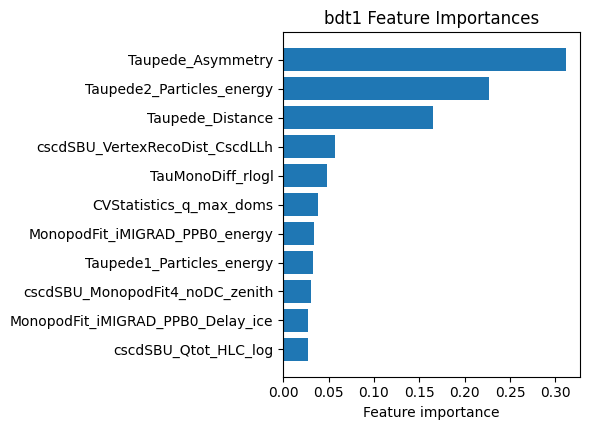

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology_trackfirst/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology_trackfirst/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology_trackfirst/bdt2_model.pkl


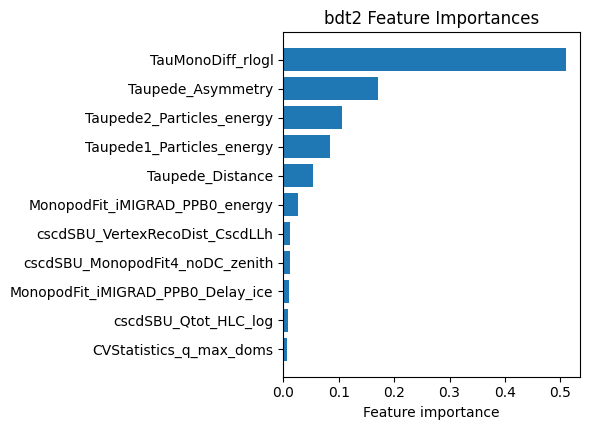

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology_trackfirst/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 34458
[weight] rate        = 4.7205e-08
[weight] uncertainty = 5.68053e-10
Calculating rates for flavor: numu
Raw event count: 42593
[weight] rate        = 2.74859e-08
[weight] uncertainty = 2.85702e-10
Calculating rates for flavor: nutau
Raw event count: 52638
[weight] rate        = 3.32846e-08
[weight] uncertainty = 4.17735e-10


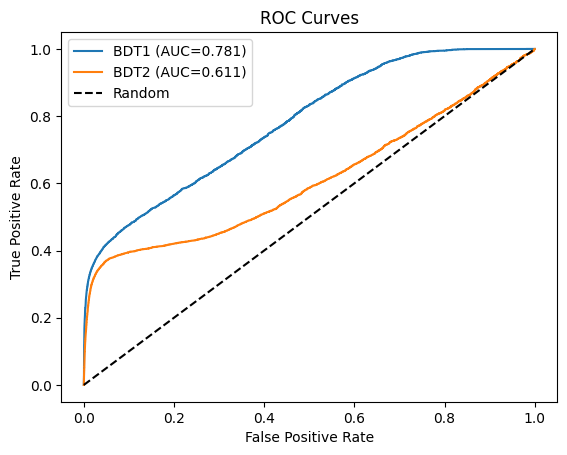

saving roc curves


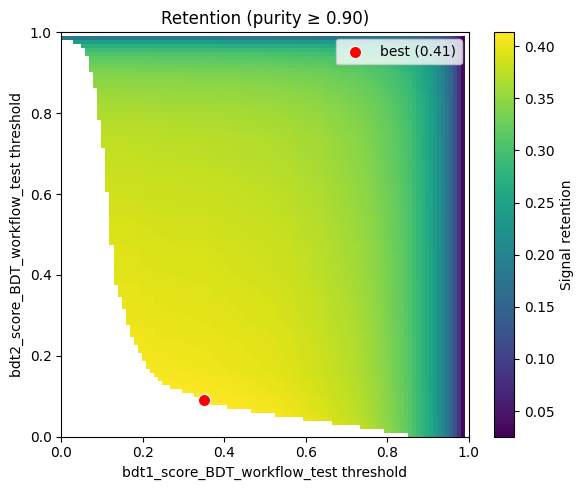


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 831
[weight] rate        = 5.37296e-10
[weight] uncertainty = 3.65469e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 2857
[weight] rate        = 4.92983e-10
[weight] uncertainty = 2.75595e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 27865
[weight] rate        = 1.10793e-08
[weight] uncertainty = 1.73828e-10


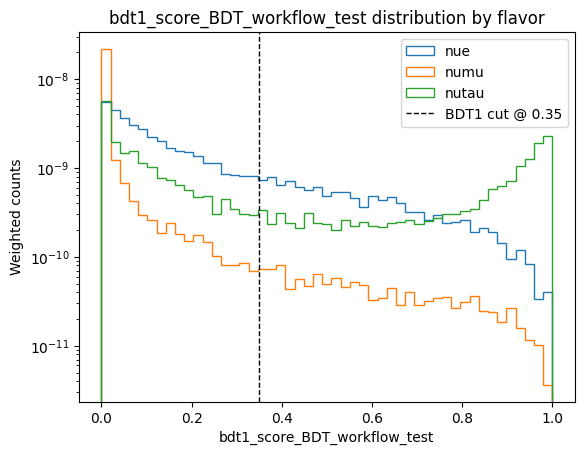

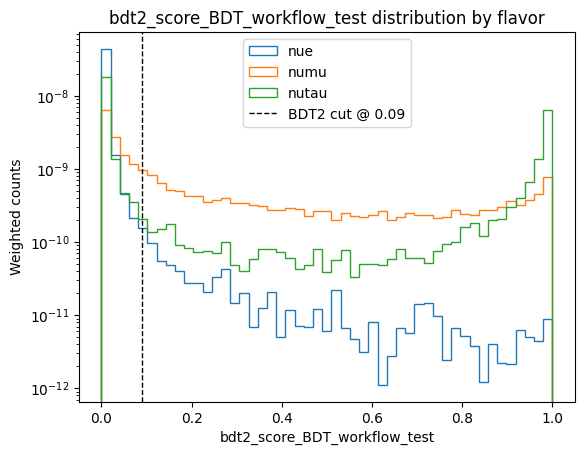

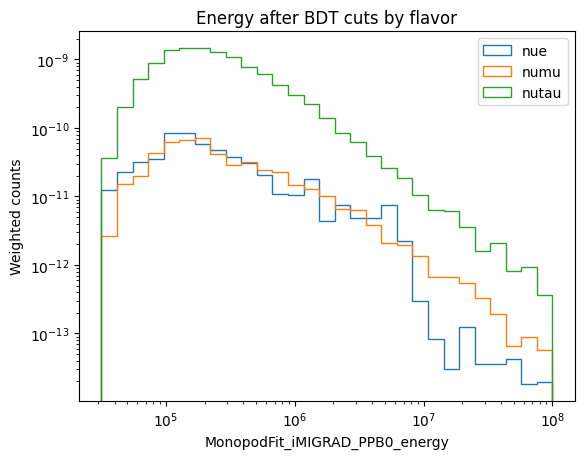


Final purity: 0.915, efficiency: 0.333


In [36]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline_hese(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/train_output_true_topology_trackfirst/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/eval_output_true_topology_trackfirst/'
) 

Volgorde maakt niets uit. 